In [35]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.optimizers import Adam

In [36]:
base_dir = "/Users/vihangainduwara/Desktop/MelanoDetect/data/ham10000"

metadata_path = os.path.join(base_dir, "HAM10000_metadata.csv")
image_dir_1 = os.path.join(base_dir, "HAM10000_images_part_1")
image_dir_2 = os.path.join(base_dir, "HAM10000_images_part_2")

print("Metadata exists:", os.path.exists(metadata_path))
print("Image dir 1 exists:", os.path.exists(image_dir_1))
print("Image dir 2 exists:", os.path.exists(image_dir_2))

Metadata exists: True
Image dir 1 exists: True
Image dir 2 exists: True


In [37]:
df = pd.read_csv(metadata_path)
print(df.shape)
df.head()

(10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [38]:
def get_image_path(image_id):
    file_name = image_id + ".jpg"

    path1 = os.path.join(image_dir_1, file_name)
    path2 = os.path.join(image_dir_2, file_name)

    if os.path.exists(path1):
        return path1
    elif os.path.exists(path2):
        return path2
    else:
        return None

df["image_path"] = df["image_id"].apply(get_image_path)
df = df.dropna(subset=["image_path"]).copy()

print("Remaining rows:", len(df))

Remaining rows: 10015


In [39]:
binary_map = {
    "mel": "malignant",
    "bcc": "malignant",
    "akiec": "malignant",
    "nv": "benign",
    "bkl": "benign",
    "df": "benign",
    "vasc": "benign"
}

df["binary_label"] = df["dx"].map(binary_map)
df["label_num"] = df["binary_label"].map({"benign": 0, "malignant": 1})

print(df["binary_label"].value_counts())

binary_label
benign       8061
malignant    1954
Name: count, dtype: int64


In [40]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label_num"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label_num"],
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 7010
Validation size: 1502
Test size: 1503


In [41]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label_num"]),
    y=train_df["label_num"]
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(0.6212336051045728), 1: np.float64(2.5621345029239766)}


In [42]:
IMG_SIZE = 240
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()

In [43]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 7010 validated image filenames belonging to 2 classes.
Found 1502 validated image filenames belonging to 2 classes.
Found 1503 validated image filenames belonging to 2 classes.


In [44]:
base_model = EfficientNetB1(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 240, 240,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 240, 240,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 240, 240,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 241, 241,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 120, 120,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 120, 120,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 120, 120,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 120, 120,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 120, 120,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 120, 120,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 120, 120,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 120, 120,  │        512 │ block1a_se_excit

 Total params: 6,908,552 (26.35 MB)

 Trainable params: 330,753 (1.26 MB)

 Non-trainable params: 6,577,799 (25.09 MB)

In [45]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        "efficientnet_b1_stage1_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
history_stage1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
158/220 ━━━━━━━━━━━━━━━━━━━━ 33s 541ms/step - accuracy: 0.6728 - loss: 0.7742

In [13]:
from tensorflow.keras.models import load_model

model = load_model("efficientnet_b1_stage1_best.keras")
print("B1 best model loaded")

B1 best model loaded


In [14]:
y_probs = model.predict(test_generator).flatten()
y_true = test_df["label_num"].values

print("Predictions:", len(y_probs))
print("Sample probs:", y_probs[:10])

47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 480ms/step
Predictions: 1503
Sample probs: [4.6555471e-01 7.9492432e-01 9.4213194e-01 7.0752281e-01 1.7064040e-04
 9.9345982e-02 7.4855285e-05 7.0659131e-05 1.8144356e-01 2.2088882e-01]


Accuracy: 0.7977378576180971
              precision    recall  f1-score   support

      Benign       0.95      0.79      0.86      1210
   Malignant       0.49      0.83      0.61       293

    accuracy                           0.80      1503
   macro avg       0.72      0.81      0.74      1503
weighted avg       0.86      0.80      0.81      1503



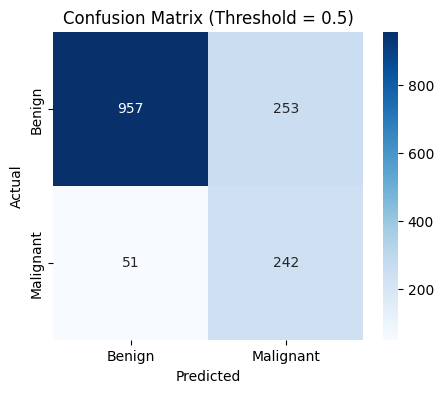

In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = (y_probs > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=["Benign", "Malignant"]))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"])
plt.title("Confusion Matrix (Threshold = 0.5)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


===== Threshold = 0.5 =====
Accuracy: 0.7977
              precision    recall  f1-score   support

      Benign       0.95      0.79      0.86      1210
   Malignant       0.49      0.83      0.61       293

    accuracy                           0.80      1503
   macro avg       0.72      0.81      0.74      1503
weighted avg       0.86      0.80      0.81      1503



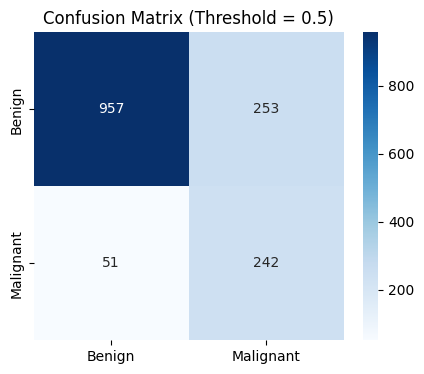


===== Threshold = 0.45 =====
Accuracy: 0.7784
              precision    recall  f1-score   support

      Benign       0.96      0.76      0.85      1210
   Malignant       0.46      0.86      0.60       293

    accuracy                           0.78      1503
   macro avg       0.71      0.81      0.72      1503
weighted avg       0.86      0.78      0.80      1503



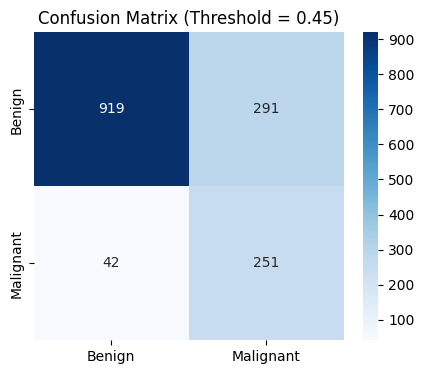


===== Threshold = 0.4 =====
Accuracy: 0.7578
              precision    recall  f1-score   support

      Benign       0.96      0.73      0.83      1210
   Malignant       0.44      0.88      0.59       293

    accuracy                           0.76      1503
   macro avg       0.70      0.80      0.71      1503
weighted avg       0.86      0.76      0.78      1503



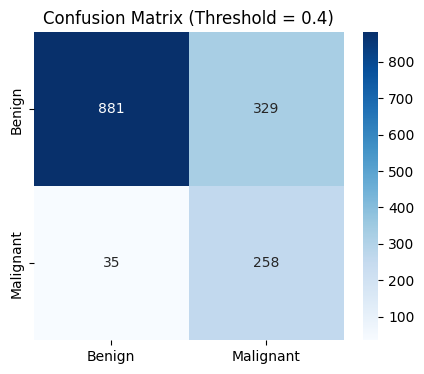


===== Threshold = 0.35 =====
Accuracy: 0.7312
              precision    recall  f1-score   support

      Benign       0.97      0.69      0.81      1210
   Malignant       0.41      0.90      0.57       293

    accuracy                           0.73      1503
   macro avg       0.69      0.80      0.69      1503
weighted avg       0.86      0.73      0.76      1503



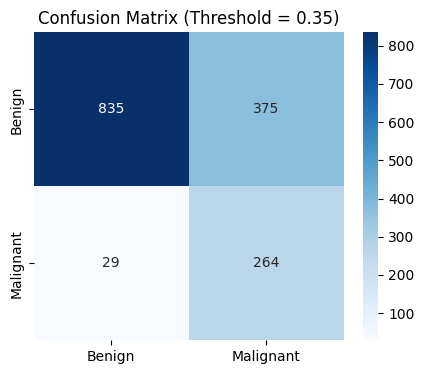


===== Threshold = 0.3 =====
Accuracy: 0.7119
              precision    recall  f1-score   support

      Benign       0.97      0.66      0.79      1210
   Malignant       0.40      0.92      0.56       293

    accuracy                           0.71      1503
   macro avg       0.69      0.79      0.67      1503
weighted avg       0.86      0.71      0.74      1503



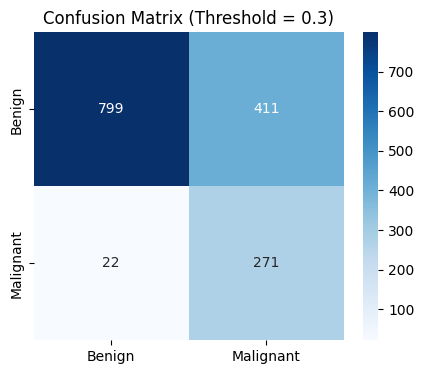

In [16]:
thresholds = [0.5, 0.45, 0.4, 0.35, 0.3]

for threshold in thresholds:
    y_pred = (y_probs > threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n===== Threshold = {threshold} =====")
    print("Accuracy:", round(acc, 4))
    print(classification_report(y_true, y_pred,
          target_names=["Benign", "Malignant"], zero_division=0))

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Benign", "Malignant"],
                yticklabels=["Benign", "Malignant"])
    plt.title(f"Confusion Matrix (Threshold = {threshold})")
    plt.show()

In [24]:
IMG_SIZE = (260, 260)
BATCH_SIZE = 32

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="binary_num",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",   # important because binary_num is 0/1 numeric
    shuffle=False
)

KeyError: 'binary_num'

In [25]:
print(df.columns)
print(test_df.columns)

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization',
       'image_path', 'binary_label', 'label_num'],
      dtype='object')
Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization',
       'image_path', 'binary_label', 'label_num'],
      dtype='object')


from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (260, 260)
BATCH_SIZE = 32

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label_num",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

In [26]:
y_prob = model.predict(test_generator, verbose=1).flatten()
y_pred = (y_prob > 0.5).astype(int)
y_true = test_df["label_num"].values

47/47 ━━━━━━━━━━━━━━━━━━━━ 28s 571ms/step


Confusion Matrix:
[[816 394]
 [224  69]]


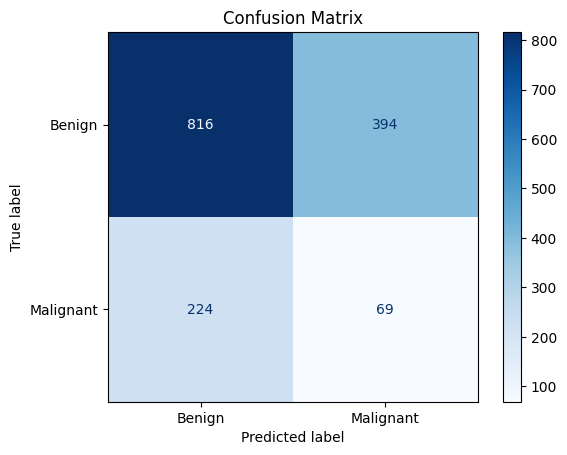

In [27]:
im=

In [28]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=["Benign", "Malignant"]))

Classification Report:
              precision    recall  f1-score   support

      Benign       0.78      0.67      0.73      1210
   Malignant       0.15      0.24      0.18       293

    accuracy                           0.59      1503
   macro avg       0.47      0.45      0.45      1503
weighted avg       0.66      0.59      0.62      1503



In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Accuracy  : 0.5888
Precision : 0.1490
Recall    : 0.2355
F1-Score  : 0.1825


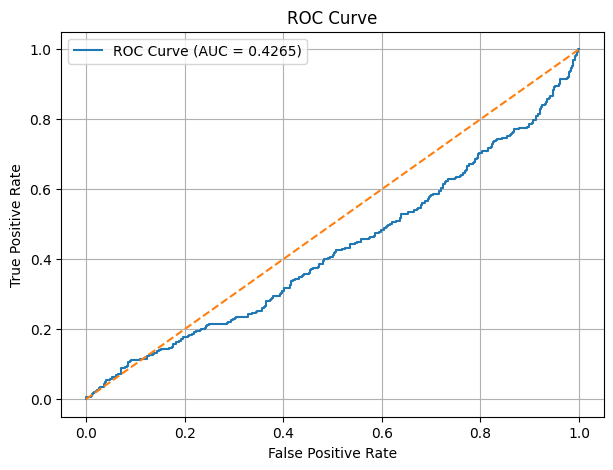

AUC Score : 0.4265


In [30]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

print(f"AUC Score : {roc_auc:.4f}")

In [31]:
print(history.history.keys())

NameError: name 'history' is not defined

In [32]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(7, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(7, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'history' is not defined

<Figure size 700x500 with 0 Axes>

In [33]:
import os
print(os.listdir("."))
print(os.listdir(".."))

['04_input_validator.ipynb', '.DS_Store', '06_efficientnet_b1_binary.ipynb', '02_dataset_exploration.ipynb', '.ipynb_checkpoints', '05_efficientnet_binary_improved.ipynb', '03_efficientnet_binary..ipynb', '01_initial_dataset_work.ipynb']
['.venv-1', '.DS_Store', 'app', 'requirements.txt', 'models', 'docs', 'README.md', 'results', '.gitignore', '.venv', '.git', 'data', 'notebooks']


In [1]:
# Get predictions from model
y_prob = model.predict(test_images, verbose=1)

# Convert to 1D
y_prob = y_prob.flatten()

# Apply your threshold (IMPORTANT - use 0.45)
threshold = 0.45
y_pred = (y_prob >= threshold).astype(int)

# True labels
y_true = test_labels

NameError: name 'model' is not defined

In [2]:
import os
from tensorflow.keras.models import load_model

MODEL_PATH = "/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_big260_ft10.keras"

model = load_model(MODEL_PATH, compile=False)

print("Model loaded successfully")

Model loaded successfully


In [3]:
print("model:", "model" in globals())
print("test_images:", "test_images" in globals())
print("test_labels:", "test_labels" in globals())

model: True
test_images: False
test_labels: False


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (260, 260)
BATCH_SIZE = 32

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Test generator created")
print("Samples:", test_generator.samples)
print("Classes:", test_generator.class_indices)

NameError: name 'test_df' is not defined

In [5]:
print("df:", "df" in globals())
print("train_df:", "train_df" in globals())
print("val_df:", "val_df" in globals())
print("test_df:", "test_df" in globals())

df: False
train_df: False
val_df: False
test_df: False


In [6]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

base_dir = "/Users/vihangainduwara/Desktop/MelanoDetect/data/ham10000"

metadata_path = os.path.join(base_dir, "HAM10000_metadata.csv")
image_dir_1 = os.path.join(base_dir, "HAM10000_images_part_1")
image_dir_2 = os.path.join(base_dir, "HAM10000_images_part_2")

df = pd.read_csv(metadata_path)

def get_image_path(image_id):
    file_name = image_id + ".jpg"
    path1 = os.path.join(image_dir_1, file_name)
    path2 = os.path.join(image_dir_2, file_name)

    if os.path.exists(path1):
        return path1
    elif os.path.exists(path2):
        return path2
    return None

df["image_path"] = df["image_id"].apply(get_image_path)
df = df.dropna(subset=["image_path"])

binary_map = {
    "mel": "malignant",
    "bcc": "malignant",
    "akiec": "malignant",
    "nv": "benign",
    "bkl": "benign",
    "vasc": "benign",
    "df": "benign"
}

df["binary_label"] = df["dx"].map(binary_map)
df = df.dropna(subset=["binary_label"])

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["binary_label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["binary_label"],
    random_state=42
)

print("Total:", len(df))
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))
print(test_df["binary_label"].value_counts())

Total: 10015
Train: 7010
Validation: 1502
Test: 1503
binary_label
benign       1210
malignant     293
Name: count, dtype: int64


In [7]:
test_generator.reset()

y_prob = model.predict(test_generator, verbose=1).flatten()

threshold = 0.45
y_pred = (y_prob >= threshold).astype(int)

y_true = test_generator.classes

print("y_true:", y_true.shape)
print("y_pred:", y_pred.shape)
print("y_prob:", y_prob.shape)

NameError: name 'test_generator' is not defined

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (260, 260)
BATCH_SIZE = 32

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Test generator created")
print("Samples:", test_generator.samples)
print("Classes:", test_generator.class_indices)

Found 1503 validated image filenames belonging to 2 classes.
Test generator created
Samples: 1503
Classes: {'benign': 0, 'malignant': 1}


In [9]:
test_generator.reset()

y_prob = model.predict(test_generator, verbose=1).flatten()

threshold = 0.45
y_pred = (y_prob >= threshold).astype(int)

y_true = test_generator.classes

print("y_true:", y_true.shape)
print("y_pred:", y_pred.shape)
print("y_prob:", y_prob.shape)

47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 442ms/step


AttributeError: 'list' object has no attribute 'shape'

In [10]:
import numpy as np

test_generator.reset()

y_prob = model.predict(test_generator, verbose=1).flatten()

threshold = 0.45
y_pred = (y_prob >= threshold).astype(int)

y_true = np.array(test_generator.classes)

print("y_true:", y_true.shape)
print("y_pred:", y_pred.shape)
print("y_prob:", y_prob.shape)

47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 429ms/step
y_true: (1503,)
y_pred: (1503,)
y_prob: (1503,)


In [11]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred)
print(cm)

print(classification_report(
    y_true,
    y_pred,
    target_names=["Benign", "Malignant"]
))

[[1210    0]
 [ 293    0]]
              precision    recall  f1-score   support

      Benign       0.81      1.00      0.89      1210
   Malignant       0.00      0.00      0.00       293

    accuracy                           0.81      1503
   macro avg       0.40      0.50      0.45      1503
weighted avg       0.65      0.81      0.72      1503



/opt/anaconda3/envs/melanodetect/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/melanodetect/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/melanodetect/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [12]:
from tensorflow.keras.applications.efficientnet import preprocess_input

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [13]:
from tensorflow.keras.models import load_model

MODEL_PATH = "/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_big260_ft10.keras"

model = load_model(MODEL_PATH, compile=False)
print("Model loaded")

Model loaded


In [14]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = (260, 260)
BATCH_SIZE = 32

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Samples:", test_generator.samples)
print("Class indices:", test_generator.class_indices)

Found 1503 validated image filenames belonging to 2 classes.
Samples: 1503
Class indices: {'benign': 0, 'malignant': 1}


In [15]:
test_generator.reset()

y_prob = model.predict(test_generator, verbose=1).flatten()

threshold = 0.45
y_pred = (y_prob >= threshold).astype(int)

y_true = np.array(test_generator.classes)

print("y_true:", y_true.shape)
print("y_pred:", y_pred.shape)
print("y_prob:", y_prob.shape)

print("Probability min:", y_prob.min())
print("Probability max:", y_prob.max())
print("Probability mean:", y_prob.mean())

47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 444ms/step
y_true: (1503,)
y_pred: (1503,)
y_prob: (1503,)
Probability min: 0.052837346
Probability max: 0.78913337
Probability mean: 0.3181977


In [16]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

cm = confusion_matrix(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)

print("Accuracy:", round(acc * 100, 2), "%")
print("Confusion Matrix:")
print(cm)

print(classification_report(
    y_true,
    y_pred,
    target_names=["Benign", "Malignant"],
    zero_division=0
))

Accuracy: 84.5 %
Confusion Matrix:
[[1076  134]
 [  99  194]]
              precision    recall  f1-score   support

      Benign       0.92      0.89      0.90      1210
   Malignant       0.59      0.66      0.62       293

    accuracy                           0.84      1503
   macro avg       0.75      0.78      0.76      1503
weighted avg       0.85      0.84      0.85      1503



In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

thresholds = [0.30, 0.35, 0.40, 0.42, 0.45, 0.48, 0.50]

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

    acc = accuracy_score(y_true, y_pred_t)
    precision = precision_score(y_true, y_pred_t, zero_division=0)
    recall = recall_score(y_true, y_pred_t, zero_division=0)
    f1 = f1_score(y_true, y_pred_t, zero_division=0)
    cm = confusion_matrix(y_true, y_pred_t)

    print(f"\nThreshold: {t}")
    print(f"Accuracy: {acc*100:.2f}%")
    print(f"Malignant Precision: {precision*100:.2f}%")
    print(f"Malignant Recall: {recall*100:.2f}%")
    print(f"Malignant F1: {f1*100:.2f}%")
    print(cm)


Threshold: 0.3
Accuracy: 66.53%
Malignant Precision: 36.57%
Malignant Recall: 97.61%
Malignant F1: 53.21%
[[714 496]
 [  7 286]]

Threshold: 0.35
Accuracy: 73.85%
Malignant Precision: 42.16%
Malignant Recall: 91.81%
Malignant F1: 57.79%
[[841 369]
 [ 24 269]]

Threshold: 0.4
Accuracy: 79.64%
Malignant Precision: 48.69%
Malignant Recall: 82.25%
Malignant F1: 61.17%
[[956 254]
 [ 52 241]]

Threshold: 0.42
Accuracy: 81.70%
Malignant Precision: 52.08%
Malignant Recall: 76.79%
Malignant F1: 62.07%
[[1003  207]
 [  68  225]]

Threshold: 0.45
Accuracy: 84.50%
Malignant Precision: 59.15%
Malignant Recall: 66.21%
Malignant F1: 62.48%
[[1076  134]
 [  99  194]]

Threshold: 0.48
Accuracy: 85.30%
Malignant Precision: 64.29%
Malignant Recall: 55.29%
Malignant F1: 59.45%
[[1120   90]
 [ 131  162]]

Threshold: 0.5
Accuracy: 85.70%
Malignant Precision: 69.12%
Malignant Recall: 48.12%
Malignant F1: 56.74%
[[1147   63]
 [ 152  141]]


In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve
)

SAVE_DIR = "/Users/vihangainduwara/Desktop/MelanoDetect/results/report_charts"
os.makedirs(SAVE_DIR, exist_ok=True)

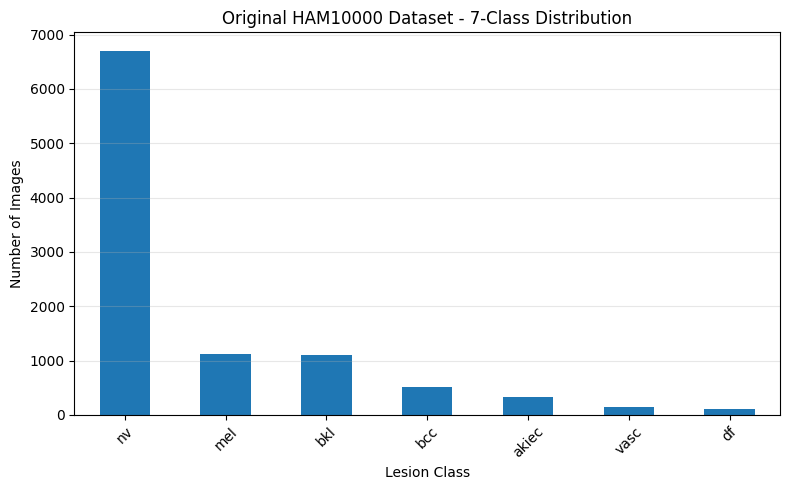

In [19]:
class_counts = df["dx"].value_counts()

plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar")
plt.title("Original HAM10000 Dataset - 7-Class Distribution")
plt.xlabel("Lesion Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "01_original_7_class_distribution.png"), dpi=300)
plt.show()

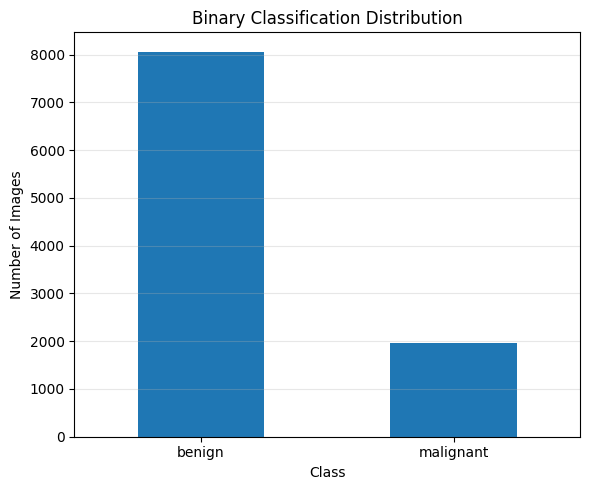

In [20]:
binary_counts = df["binary_label"].value_counts()

plt.figure(figsize=(6, 5))
binary_counts.plot(kind="bar")
plt.title("Binary Classification Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "02_binary_distribution.png"), dpi=300)
plt.show()

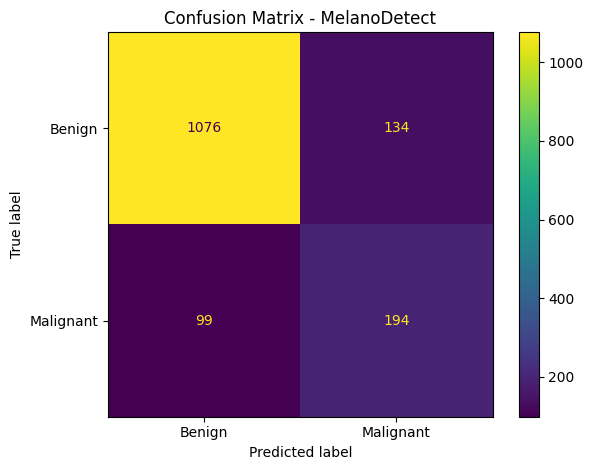

In [21]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix - MelanoDetect")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "03_confusion_matrix.png"), dpi=300)
plt.show()

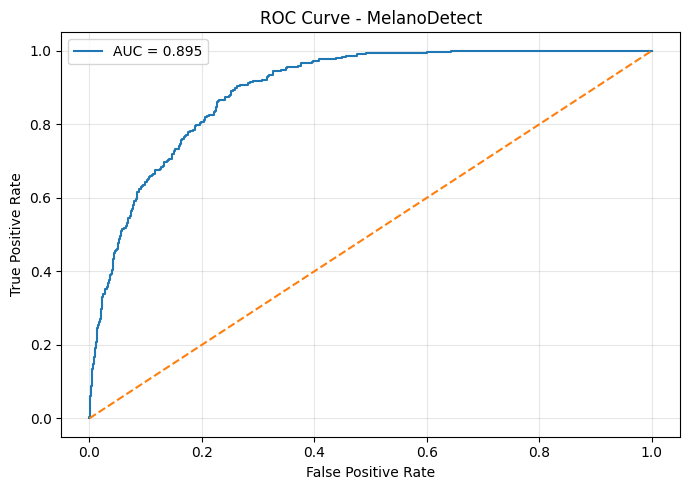

In [22]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve - MelanoDetect")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "04_roc_curve.png"), dpi=300)
plt.show()

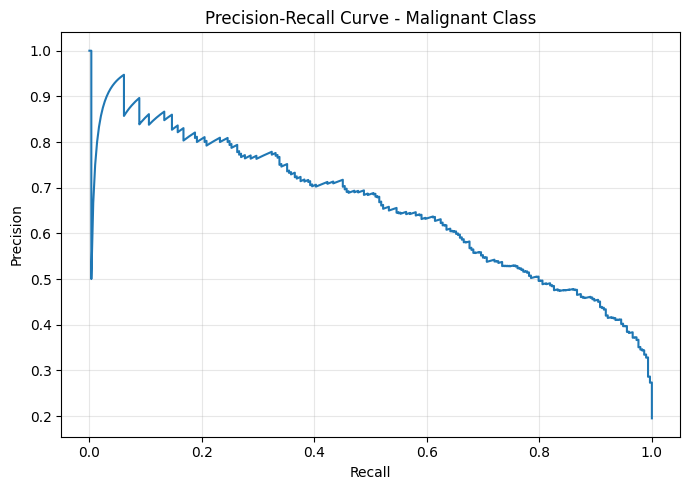

In [23]:
precision, recall, _ = precision_recall_curve(y_true, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.title("Precision-Recall Curve - Malignant Class")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "05_precision_recall_curve.png"), dpi=300)
plt.show()

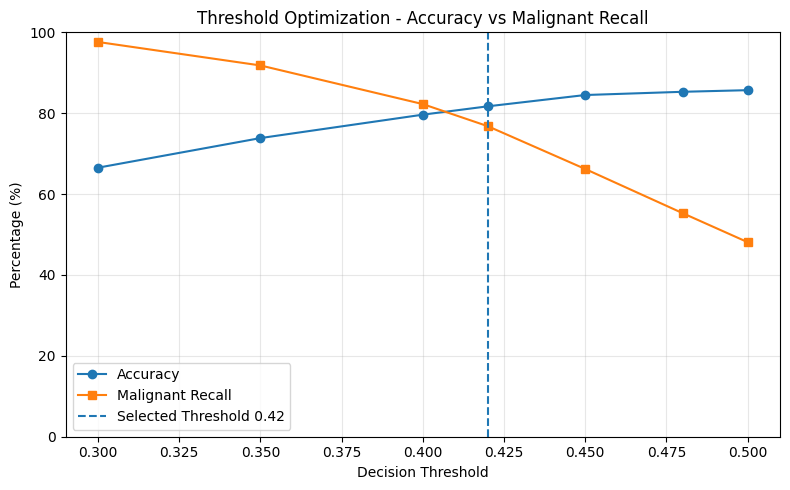

In [24]:
thresholds = [0.30, 0.35, 0.40, 0.42, 0.45, 0.48, 0.50]

acc_list = []
precision_list = []
recall_list = []
f1_list = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

    acc_list.append(accuracy_score(y_true, y_pred_t) * 100)
    precision_list.append(precision_score(y_true, y_pred_t, zero_division=0) * 100)
    recall_list.append(recall_score(y_true, y_pred_t, zero_division=0) * 100)
    f1_list.append(f1_score(y_true, y_pred_t, zero_division=0) * 100)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, acc_list, marker="o", label="Accuracy")
plt.plot(thresholds, recall_list, marker="s", label="Malignant Recall")
plt.axvline(x=0.42, linestyle="--", label="Selected Threshold 0.42")
plt.title("Threshold Optimization - Accuracy vs Malignant Recall")
plt.xlabel("Decision Threshold")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "06_threshold_optimization.png"), dpi=300)
plt.show()

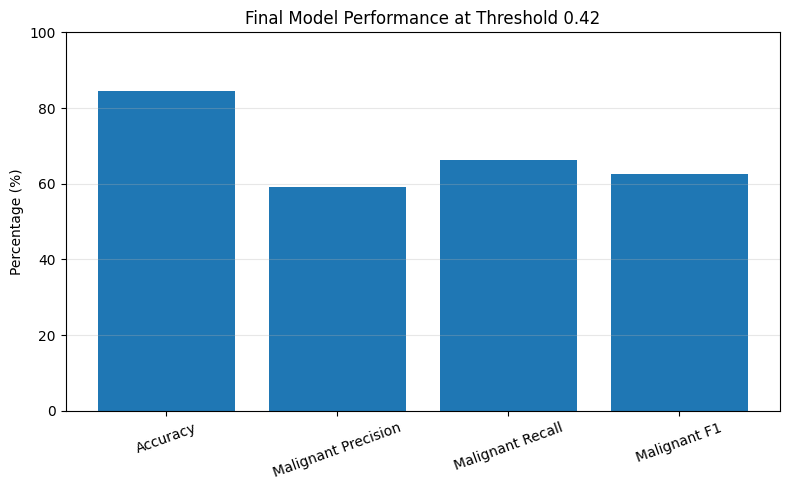

In [25]:
final_metrics = {
    "Accuracy": accuracy_score(y_true, y_pred) * 100,
    "Malignant Precision": precision_score(y_true, y_pred, zero_division=0) * 100,
    "Malignant Recall": recall_score(y_true, y_pred, zero_division=0) * 100,
    "Malignant F1": f1_score(y_true, y_pred, zero_division=0) * 100
}

plt.figure(figsize=(8, 5))
plt.bar(final_metrics.keys(), final_metrics.values())
plt.title("Final Model Performance at Threshold 0.42")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "07_final_model_performance.png"), dpi=300)
plt.show()

In [28]:
print(type(_23))

<class 'str'>


In [30]:
hist = _23.history

acc_key = "accuracy" if "accuracy" in hist else "binary_accuracy"
val_acc_key = "val_accuracy" if "val_accuracy" in hist else "val_binary_accuracy"

plt.figure(figsize=(7, 5))
plt.plot(hist[acc_key], label="Training Accuracy")
plt.plot(hist[val_acc_key], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "08_training_validation_accuracy.png"), dpi=300)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(hist["loss"], label="Training Loss")
plt.plot(hist["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "09_training_validation_loss.png"), dpi=300)
plt.show()

AttributeError: 'str' object has no attribute 'history'

In [31]:
for name in globals().keys():
    if "history" in name.lower():
        print(name)

RuntimeError: dictionary changed size during iteration

In [32]:
for name in list(globals().keys()):
    if "history" in name.lower():
        print(name, type(globals()[name]))

In [33]:
<class 'keras.src.callbacks.history.History'>

SyntaxError: invalid syntax (1061273660.py, line 1)

In [34]:
for name in list(globals().keys()):
    obj = globals()[name]
    if hasattr(obj, "history"):
        print(name, type(obj), obj.history.keys())

In [35]:
hist = VARIABLE_NAME.history

NameError: name 'VARIABLE_NAME' is not defined

In [36]:
history_objects = []

for name in list(globals().keys()):
    obj = globals()[name]
    if hasattr(obj, "history") and isinstance(obj.history, dict):
        history_objects.append(name)
        print("FOUND:", name)
        print("KEYS:", obj.history.keys())

print("All history objects:", history_objects)

All history objects: []


In [37]:
hist = history.history

NameError: name 'history' is not defined

In [38]:
import os
import matplotlib.pyplot as plt

acc_key = "accuracy" if "accuracy" in hist else "binary_accuracy"
val_acc_key = "val_accuracy" if "val_accuracy" in hist else "val_binary_accuracy"

plt.figure(figsize=(7, 5))
plt.plot(hist[acc_key], label="Training Accuracy")
plt.plot(hist[val_acc_key], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "08_training_validation_accuracy.png"), dpi=300)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(hist["loss"], label="Training Loss")
plt.plot(hist["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "09_training_validation_loss.png"), dpi=300)
plt.show()

NameError: name 'hist' is not defined

In [39]:
history_objects = []

for name in list(globals().keys()):
    obj = globals()[name]
    if hasattr(obj, "history") and isinstance(obj.history, dict):
        history_objects.append(name)
        print("FOUND:", name)
        print(obj.history.keys())

print(history_objects)

[]


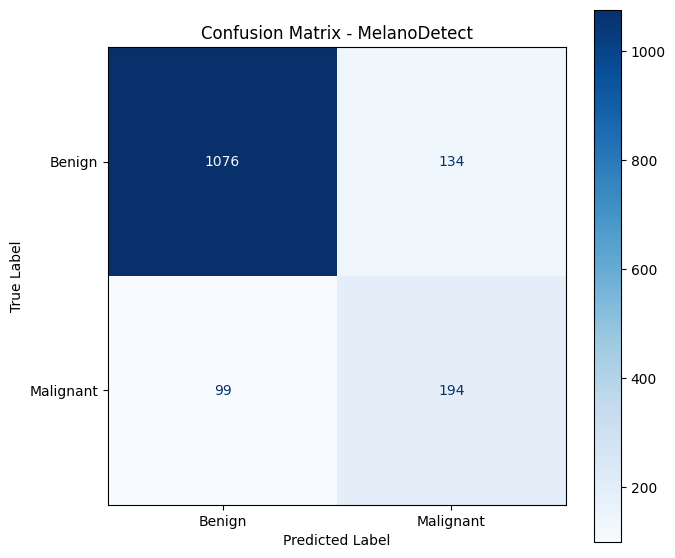

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)

plt.title("Confusion Matrix - MelanoDetect")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

plt.savefig(os.path.join(SAVE_DIR, "03_confusion_matrix_blue.png"), dpi=300, bbox_inches="tight")
plt.show()

In [41]:
y_prob = model.predict(test_generator, verbose=1).flatten()
y_true = test_generator.classes

47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 429ms/step


In [42]:
threshold = 0.42
y_pred = (y_prob >= threshold).astype(int)

In [43]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

cm = confusion_matrix(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)

print("Threshold:", threshold)
print("Accuracy:", round(acc * 100, 2), "%")
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Benign", "Malignant"],
    zero_division=0
))

Threshold: 0.42
Accuracy: 81.7 %
Confusion Matrix:
[[1003  207]
 [  68  225]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.94      0.83      0.88      1210
   Malignant       0.52      0.77      0.62       293

    accuracy                           0.82      1503
   macro avg       0.73      0.80      0.75      1503
weighted avg       0.86      0.82      0.83      1503



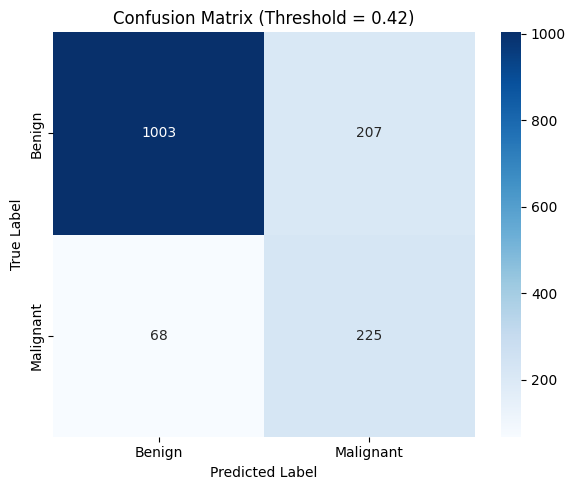

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",  # 🔵 Blue theme
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.title("Confusion Matrix (Threshold = 0.42)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

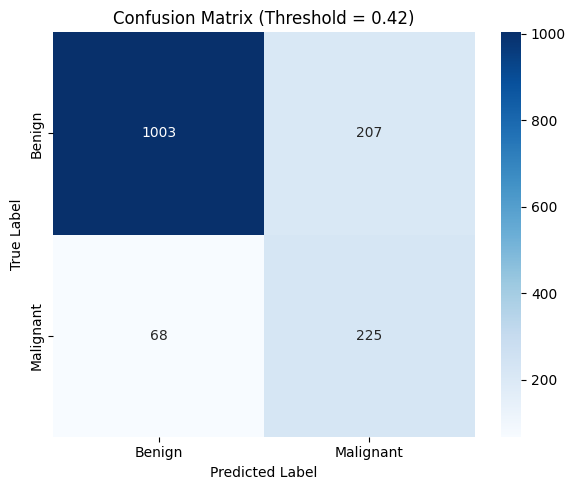

In [45]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.title("Confusion Matrix (Threshold = 0.42)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

# ✅ SAVE IMAGE HERE
plt.savefig("confusion_matrix_042.png", dpi=300)

plt.show()

In [46]:
SAVE_DIR = "/Users/vihangainduwara/Desktop/MelanoDetect/results/report_charts"

import os
os.makedirs(SAVE_DIR, exist_ok=True)

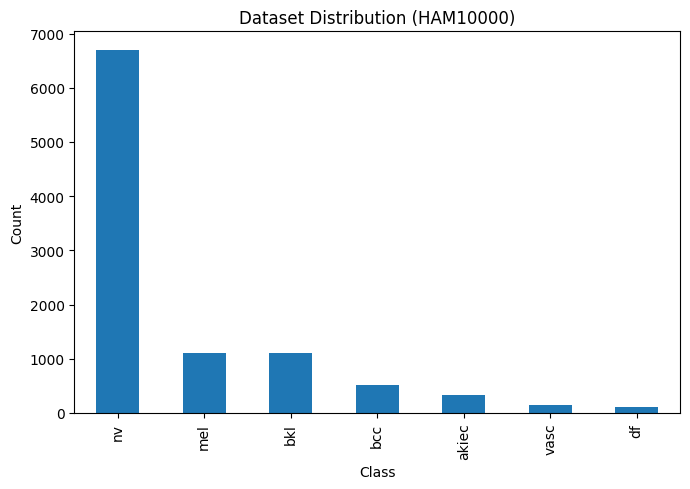

In [47]:
import matplotlib.pyplot as plt

class_counts = df["dx"].value_counts()

plt.figure(figsize=(7,5))
class_counts.plot(kind="bar")
plt.title("Dataset Distribution (HAM10000)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()

plt.savefig(os.path.join(SAVE_DIR, "01_dataset_distribution.png"), dpi=300)
plt.show()

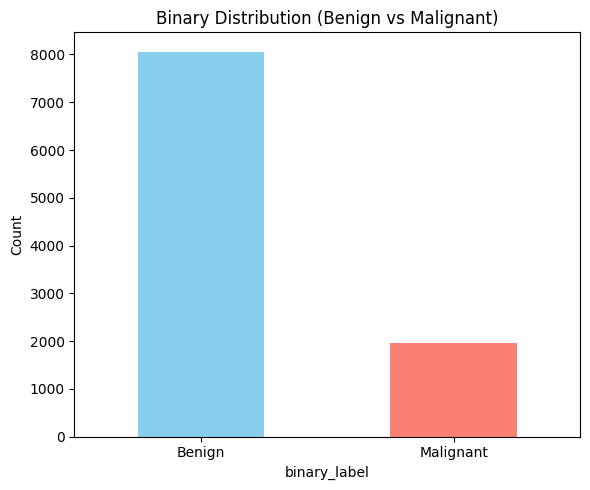

In [48]:
binary_counts = df["binary_label"].value_counts()

plt.figure(figsize=(6,5))
binary_counts.plot(kind="bar", color=["skyblue","salmon"])
plt.title("Binary Distribution (Benign vs Malignant)")
plt.xticks([0,1], ["Benign", "Malignant"], rotation=0)
plt.ylabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "02_binary_distribution.png"), dpi=300)
plt.show()

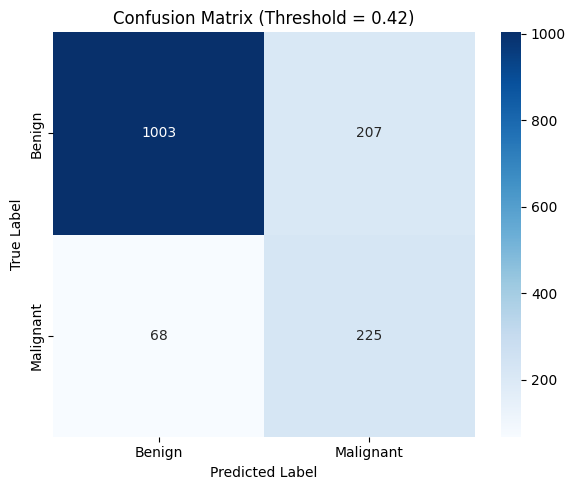

In [49]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

threshold = 0.42
y_pred = (y_prob >= threshold).astype(int)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"])

plt.title("Confusion Matrix (Threshold = 0.42)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "03_confusion_matrix_042.png"), dpi=300)
plt.show()

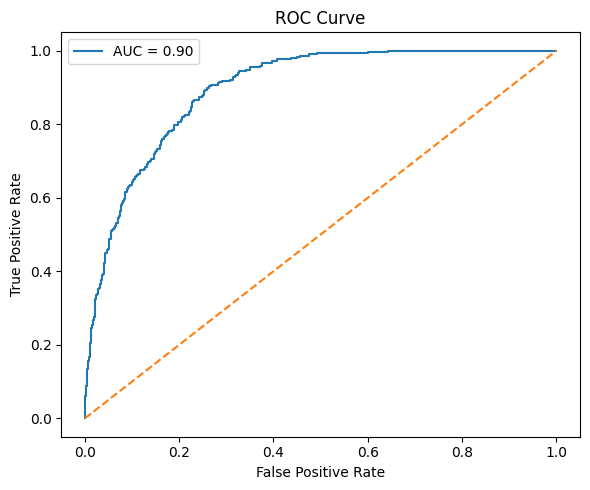

In [50]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "04_roc_curve.png"), dpi=300)
plt.show()

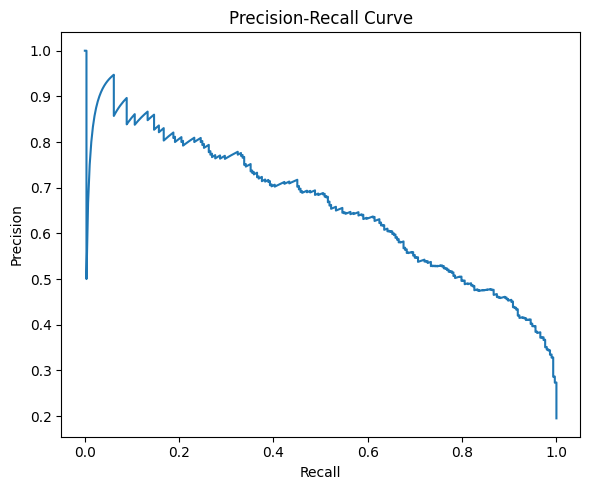

In [51]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_true, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "05_precision_recall_curve.png"), dpi=300)
plt.show()

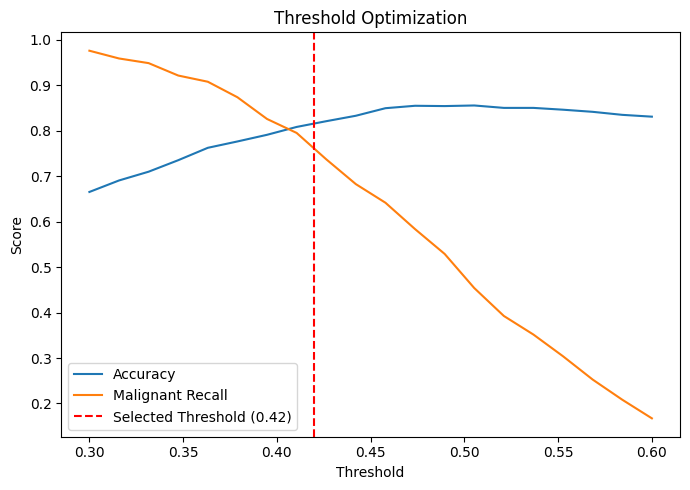

In [52]:
import numpy as np
from sklearn.metrics import accuracy_score, recall_score

thresholds = np.linspace(0.3, 0.6, 20)

acc_list = []
recall_list = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    acc_list.append(accuracy_score(y_true, y_pred_t))
    recall_list.append(recall_score(y_true, y_pred_t))

plt.figure(figsize=(7,5))
plt.plot(thresholds, acc_list, label="Accuracy")
plt.plot(thresholds, recall_list, label="Malignant Recall")

plt.axvline(x=0.42, color="red", linestyle="--", label="Selected Threshold (0.42)")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization")
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "06_threshold_optimization.png"), dpi=300)
plt.show()

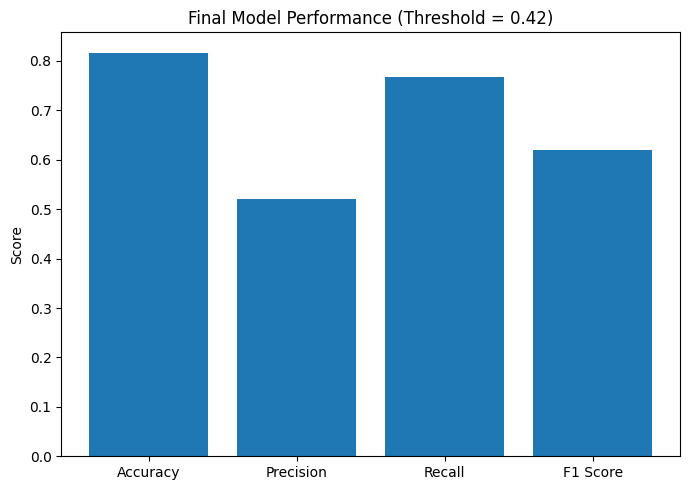

In [53]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

threshold = 0.42
y_pred = (y_prob >= threshold).astype(int)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

metrics = [acc, prec, rec, f1]
labels = ["Accuracy", "Precision", "Recall", "F1 Score"]

plt.figure(figsize=(7,5))
plt.bar(labels, metrics)

plt.title("Final Model Performance (Threshold = 0.42)")
plt.ylabel("Score")

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "07_final_performance.png"), dpi=300)
plt.show()

In [54]:
from IPython.display import display, Javascript

display(Javascript('IPython.notebook.save_checkpoint();'))

<IPython.core.display.Javascript object>

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input

SAVE_DIR = "/Users/vihangainduwara/Desktop/MelanoDetect/results/report_charts"
os.makedirs(SAVE_DIR, exist_ok=True)

THRESHOLD = 0.42
IMG_SIZE = (240, 240)  # use 260,260 only if your current model expects 260

In [2]:
# Add probabilities and predictions to test_df
test_df = test_df.copy()
test_df["prob_malignant"] = y_prob
test_df["pred_label"] = np.where(test_df["prob_malignant"] >= THRESHOLD, "malignant", "benign")

# Pick samples
malignant_sample = test_df[
    (test_df["binary_label"] == "malignant") & 
    (test_df["pred_label"] == "malignant")
].iloc[0]

benign_sample = test_df[
    (test_df["binary_label"] == "benign") & 
    (test_df["pred_label"] == "benign")
].iloc[0]

third_sample = test_df.iloc[10]

samples = [malignant_sample, benign_sample, third_sample]

NameError: name 'test_df' is not defined

In [3]:
for name in list(globals().keys()):
    if "df" in name.lower():
        print(name)

In [5]:
for name in list(globals().keys()):
    if "df" in name.lower() or "test" in name.lower():
        print(name, type(globals()[name]))